In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

In [2]:
df = pd.read_csv('../data/CC GENERAL.csv')

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (8950, 18)

Column names:
['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

First 5 rows:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nBasic statistics:")
df.describe().round(2)

Missing values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Basic statistics:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8949.00,8950.00,8637.00,8950.00,8950.00
mean,1564.47,0.88,1003.20,592.44,411.07,978.87,0.49,0.20,0.36,0.14,3.25,14.71,4494.45,1733.14,864.21,0.15,11.52
std,2081.53,0.24,2136.63,1659.89,904.34,2097.16,0.40,0.30,0.40,0.20,6.82,24.86,3638.82,2895.06,2372.45,0.29,1.34
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50.00,0.00,0.02,0.00,6.00
25%,128.28,0.89,39.64,0.00,0.00,0.00,0.08,0.00,0.00,0.00,0.00,1.00,1600.00,383.28,169.12,0.00,12.00
50%,873.39,1.00,361.28,38.00,89.00,0.00,0.50,0.08,0.17,0.00,0.00,7.00,3000.00,856.90,312.34,0.00,12.00
75%,2054.14,1.00,1110.13,577.40,468.64,1113.82,0.92,0.30,0.75,0.22,4.00,17.00,6500.00,1901.13,825.49,0.14,12.00
max,19043.14,1.00,49039.57,40761.25,22500.00,47137.21,1.00,1.00,1.00,1.50,123.00,358.00,30000.00,50721.48,76406.21,1.00,12.00


CASH_ADVANCE, PURCHASES, MINIMUM_PAYMENTS have max value much higher than mean, which implies extreme outliers

In [4]:
print("Data types:")
print(df.dtypes)

print("\nAny duplicate rows:", df.duplicated().sum())

Data types:
CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

Any duplicate rows: 0


### Cleaning & EDA

#### Clean the data

In [7]:
# Customer ID is a label not a feature
df = df.drop(columns=['CUST_ID'])

# Impute missing values with the median
# Median instead of mean because of extreme outliers

df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())


print("Missing values remaining:", df.isnull().sum().sum())
print("Shape:", df.shape)



Missing values remaining: 0
Shape: (8950, 17)


#### Check skewness

In [9]:
skewness = df.skew().sort_values(ascending=False)
print("Feature skewness :")
print(skewness.round(2))

Feature skewness :
MINIMUM_PAYMENTS                    13.85
ONEOFF_PURCHASES                    10.05
PURCHASES                            8.14
INSTALLMENTS_PURCHASES               7.30
PAYMENTS                             5.91
CASH_ADVANCE_TRX                     5.72
CASH_ADVANCE                         5.17
PURCHASES_TRX                        4.63
BALANCE                              2.39
PRC_FULL_PAYMENT                     1.94
CASH_ADVANCE_FREQUENCY               1.83
ONEOFF_PURCHASES_FREQUENCY           1.54
CREDIT_LIMIT                         1.52
PURCHASES_INSTALLMENTS_FREQUENCY     0.51
PURCHASES_FREQUENCY                  0.06
BALANCE_FREQUENCY                   -2.02
TENURE                              -2.94
dtype: float64


Anything above 1.0 is highly skewed and will need log transformation before clustering.

In [17]:
print(df['TENURE'].value_counts().sort_index())
print(f"\nUnique values: {df['TENURE'].nunique()}")
print(f"% of customers with tenure = 12: {(df['TENURE'] == 12).mean()*100:.1f}%")

TENURE
6      204
7      190
8      196
9      175
10     236
11     365
12    7584
Name: count, dtype: int64

Unique values: 7
% of customers with tenure = 12: 84.7%


#### Log-transform skewed features


In [18]:
# Log transformation pulls extreme outliers closer to the centre

skewed_features = [
    'BALANCE',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'CASH_ADVANCE_TRX',
    'PURCHASES_TRX',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'CREDIT_LIMIT'
]

df_transformed = df.copy()
for col in skewed_features:
    df_transformed[col] = np.log1p(df[col])

# Compare skewness before and after for transformed columns
comparison = pd.DataFrame({
    'Before': df[skewed_features].skew().round(2),
    'After':  df_transformed[skewed_features].skew().round(2)
})
print("Skewness before and after log transform:")
print(comparison)

Skewness before and after log transform:
                        Before  After
BALANCE                   2.39  -0.86
PURCHASES                 8.14  -0.76
ONEOFF_PURCHASES         10.05   0.19
INSTALLMENTS_PURCHASES    7.30  -0.02
CASH_ADVANCE              5.17   0.26
CASH_ADVANCE_TRX          5.72   0.94
PURCHASES_TRX             4.63   0.03
PAYMENTS                  5.91  -1.78
MINIMUM_PAYMENTS         13.85   0.27
CREDIT_LIMIT              1.52  -0.10


#### Correlation heatmap

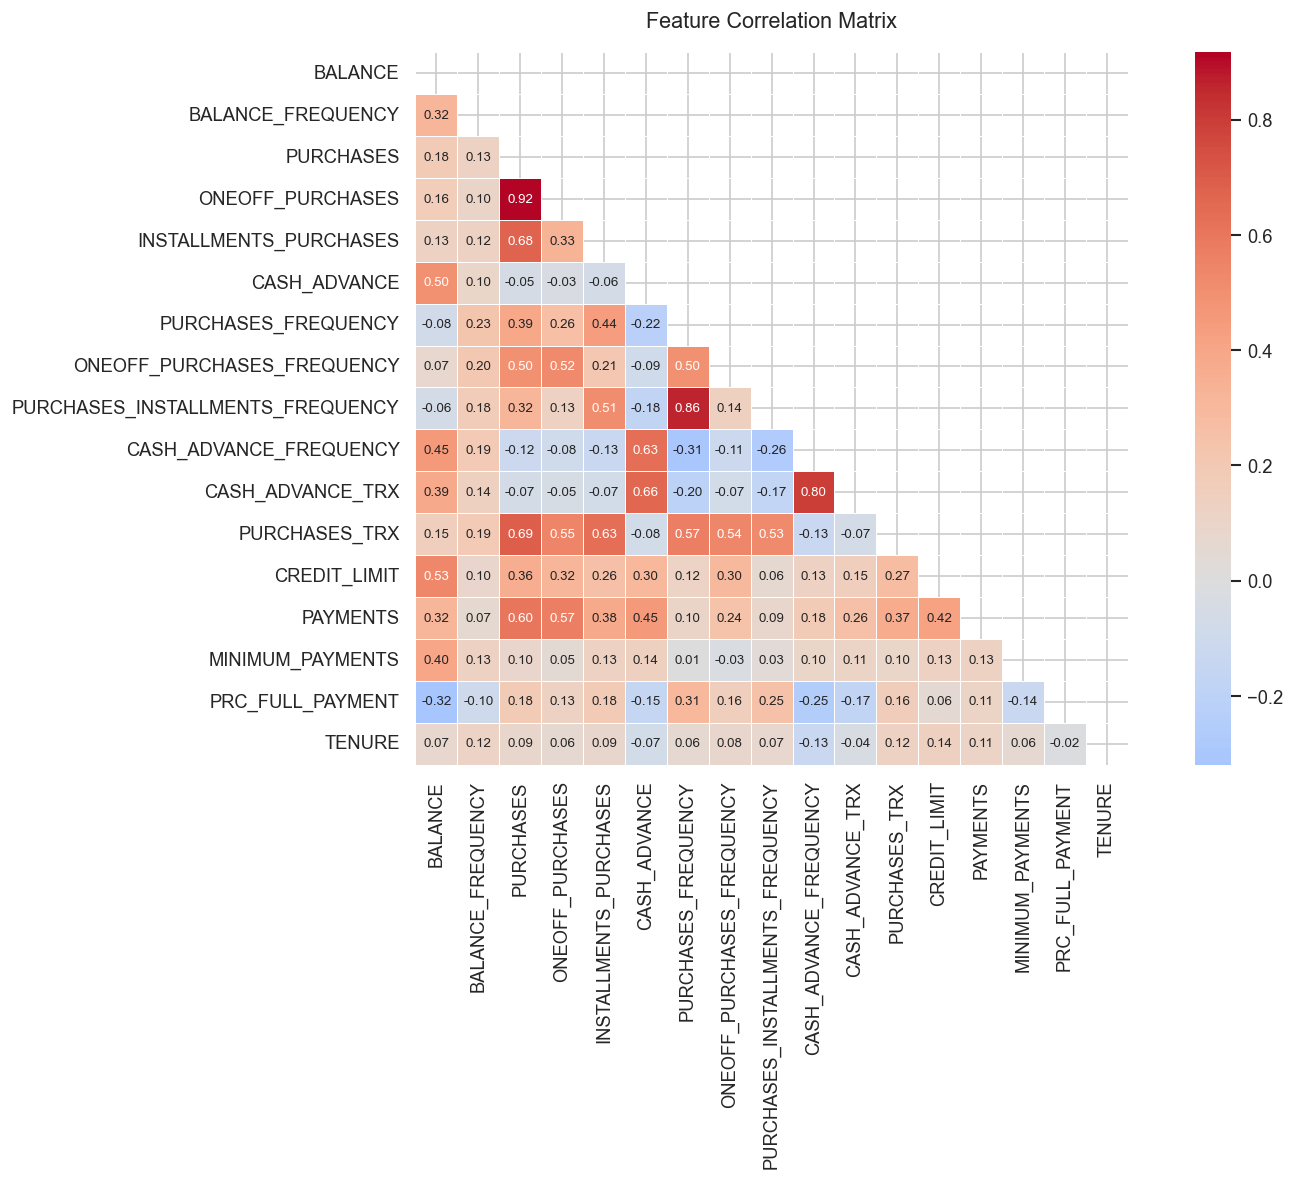

In [19]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.4,
            annot_kws={'size': 8}, ax=ax)

ax.set_title('Feature Correlation Matrix', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../outputs/02_correlation_heatmap.png', bbox_inches='tight')
plt.show()

#### Feature Engineering

In [20]:
df_transformed['PURCHASE_TO_LIMIT_RATIO'] = (
    df['PURCHASES'] / (df['CREDIT_LIMIT'] + 1)
)

df_transformed['CASH_TO_PURCHASE_RATIO'] = (
    df['CASH_ADVANCE'] / (df['PURCHASES'] + 1)
)

df_transformed['PAYMENT_TO_MINIMUM_RATIO'] = (
    df['PAYMENTS'] / (df['MINIMUM_PAYMENTS'] + 1)
)


New features:

PURCHASE_TO_LIMIT_RATIO : how much of their credit limit they actually spend

CASH_TO_PURCHASE_RATIO  : do they use the card for cash or purchases?

PAYMENT_TO_MINIMUM_RATIO : do they pay off fully or just the minimum?

#### Drop low-variance features and save cleaned dataset

In [21]:
# Tenure has almost no variance and can be dropped

df_transformed = df_transformed.drop(columns=['TENURE'])

df_transformed.to_csv('../data/cleaned_data.csv', index=False)
print("Final shape:", df_transformed.shape)

Final shape: (8950, 19)
